In [2]:
!pip install sentence-transformers
!pip install matplotlib seaborn

In [4]:
sentences = [
    # Cricket
    "The bowler took three wickets in one over.",
    "The batsman scored a century in the match.",
    "The team won the match by chasing a huge target.",

    # Cooking
    "I cooked pasta with tomato sauce.",
    "Baking a cake requires flour, sugar, and eggs.",
    "Grilling chicken takes about 30 minutes.",

    # Cybersecurity
    "Strong passwords help protect your accounts.",
    "Hackers use phishing attacks to steal data.",
    "Two-factor authentication improves security.",

    # Extra
    "Data encryption keeps information safe."
]

print("Total sentences:", len(sentences))

Total sentences: 10


In [5]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns

model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences)

print("Embeddings created successfully")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embeddings created successfully


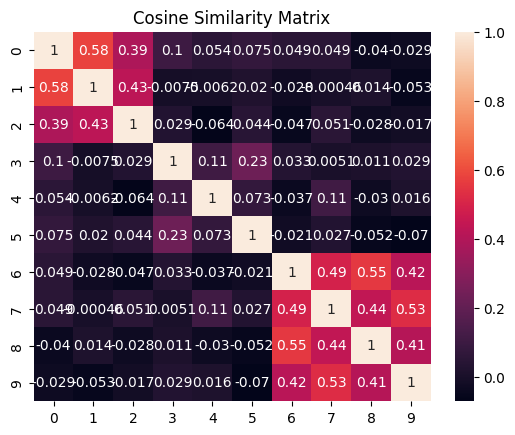

In [6]:
similarity_matrix = cosine_similarity(embeddings)

plt.figure()
sns.heatmap(similarity_matrix, annot=True)
plt.title("Cosine Similarity Matrix")
plt.show()

In [7]:
query = "The bowler took three wickets in one over"
query_embedding = model.encode([query])

similarities = cosine_similarity(query_embedding, embeddings)

print("Similarity Scores:\n")

for i, score in enumerate(similarities[0]):
    print(sentences[i], ":", score)

Similarity Scores:

The bowler took three wickets in one over. : 0.9913637
The batsman scored a century in the match. : 0.56114495
The team won the match by chasing a huge target. : 0.36326417
I cooked pasta with tomato sauce. : 0.115028515
Baking a cake requires flour, sugar, and eggs. : 0.046941385
Grilling chicken takes about 30 minutes. : 0.07201035
Strong passwords help protect your accounts. : 0.05667406
Hackers use phishing attacks to steal data. : 0.046755902
Two-factor authentication improves security. : -0.041038223
Data encryption keeps information safe. : -0.02087145


In [8]:
import numpy as np

similarity_scores = similarities[0]
top_2_idx = np.argsort(similarity_scores)[-2:][::-1]

print("\nTop 2 most similar sentences:\n")

for idx in top_2_idx:
    print(sentences[idx], "-> Score:", similarity_scores[idx])


Top 2 most similar sentences:

The bowler took three wickets in one over. -> Score: 0.9913637
The batsman scored a century in the match. -> Score: 0.56114495
